## Latent dimensionality selection for the VAE morphology embedding 

**Goal.** Choose the VAE latent dimensionality $d_z$ that best serves the paper’s objective: a compact morphology embedding that improves prediction of corrected lasing threshold beyond measured growth and nominal geometry parameters, while remaining stable and physically meaningful.

**Approach.** We perform an ablation study over $d_z \in \{4, 8, 16, 32, 64\}$. For each model we evaluate:
1) **Downstream utility** via leakage-safe cross-validation ($\Delta R^2$);  
2) **Reconstruction sanity** (visual + overlap metrics);  
3) **Embedding stability** to D4 transforms;  
4) **Latent usage** via per-dimension KL contributions.

**Leakage control.** We use GroupKFold cross-validation grouped by $(\mathrm{sample\_ID}, \mathrm{field\_ID})$ so that rings from the same field are never split across train/test folds.

### Load and validate the dataset

We first load the dataframe containing binarized edge maps and the associated growth/geometry parameters and targets. We verify that the index structure and required columns are present to ensure consistent grouping and downstream evaluation.

In [ ]:
# =========================
# Setup and library imports
# =========================

# Standard library utilities
import os, time, random, gc, json

# Core numerical and tabular libraries
import numpy as np
import pandas as pd

# PyTorch modules for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Plotting
import matplotlib.pyplot as plt

# Progress bars for loops/training
from tqdm.auto import tqdm

# OpenCV, used here for image resizing/preprocessing
import cv2

# Scikit-learn tools for cross-validation, preprocessing, regression, and metrics
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Set default display resolution for figures
plt.rcParams["figure.dpi"] = 140

# =========================
# Reproducibility
# =========================

# Fixed random seed for reproducible results
SEED = 42

# Seed Python's random module
random.seed(SEED)

# Seed NumPy random number generation
np.random.seed(SEED)

# Seed PyTorch on CPU
torch.manual_seed(SEED)

# Seed PyTorch on all available GPUs
torch.cuda.manual_seed_all(SEED)

# =========================
# Device selection
# =========================

# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# =========================
# Configuration
# Edit file paths, target column, preprocessing, training, and output settings
# =========================

# ---- input file paths ----
# Example path when running in Google Colab:
# pkl_path = "/content/drive/MyDrive/MR_Geometry_Variation_Batch_3/binarized_only_black_edge_batch_3_v2_norm.pkl"

# Example local/relative path:
pkl_path = "drive/MyDrive/MR_Geometry_Variation_Batch_3/Final_Training_Analysis_&_Results/binarized_only_black_edge_batch_3_v2_norm.pkl"

# Detect whether the notebook is running inside Google Colab
IN_COLAB = "google.colab" in str(get_ipython())

# If running in Colab, mount Google Drive and fix the path format if needed
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    
    # Convert relative Drive path to Colab's full mounted path
    if pkl_path.startswith("drive/"):
        pkl_path = "/content/" + pkl_path

# Stop execution if the dataset file does not exist
assert os.path.exists(pkl_path), f"File not found: {pkl_path}"

# ---- dataframe columns ----
# Input process/geometry parameters used as predictors
param_cols = ["diameter", "pitch", "nQWs", "growth_Temp_QW", "AsP_QW", "InP_barrier", "growth_time_cap"]

# Target variable to model
# Change to "lasing_wl_corr_from_2" if predicting wavelength instead of threshold
y_col = "lasing_threshold_corr_from_2"

# ---- image preprocessing ----
# Final image size used for model input
image_size = 128

# Whether to normalize binary masks to match area across samples
do_match_area = False

# Whether to align ring orientation before training
do_align_orientation = False

# ---- VAE training settings ----
# Number of samples per training batch
batch_size = 16

# Maximum number of training epochs
epochs = 200

# Optimizer learning rate
learning_rate = 1e-3

# Weight of the KL-divergence term in the VAE loss
beta_kl = 1.0

# Early stopping patience: stop if validation does not improve for this many epochs
patience = 15

# Minimum improvement in validation loss required to reset patience
min_delta = 1e-4

# Whether to use D4 symmetry augmentation
# Typically includes 90-degree rotations and flips
use_D4_augmentation = True

# Whether to use test-time augmentation when extracting latent vectors
use_TTA_encoding = True

# ---- latent dimension sweep + downstream regression ----
# Latent dimensions to test for the VAE
latent_dims_to_try = [4, 8, 16, 32, 64]

# Number of cross-validation splits
n_splits = 5

# Ridge regression regularization strength for downstream prediction
ridge_alpha = 1.0

# ---- output folder ----
# Create a timestamped folder name for saving results from this run
run_name = time.strftime("latent_dim_sweep_%Y%m%d_%H%M%S")

# Full output directory path
save_dir = f"./{run_name}"

# Create the output directory if it does not already exist
os.makedirs(save_dir, exist_ok=True)

# Show where outputs will be saved
save_dir

Mounted at /content/drive


'./latent_dim_sweep_20260303_110401'

In [ ]:
# =========================
# Load dataframe and validate required structure/content
# =========================

# Load the pickled pandas DataFrame from disk
df = pd.read_pickle(pkl_path)

# Check that the DataFrame index is a MultiIndex
assert isinstance(df.index, pd.MultiIndex), "Expected MultiIndex index"

# Check that the MultiIndex contains exactly the expected levels
# Required index levels: sample_ID, field_ID, ring_ID
assert set(df.index.names) == {"sample_ID", "field_ID", "ring_ID"}, \
    "Expected MultiIndex [sample_ID, field_ID, ring_ID]"

# Ensure the required image column is present
assert "binarized_black_edge_norm_faithful" in df.columns, \
    "Missing 'binarized_black_edge_norm_faithful'"

# Check whether any required metadata columns are missing
# This includes all parameter columns plus the selected target column
missing_meta = [c for c in (param_cols + [y_col]) if c not in df.columns]

# Stop execution if any required metadata columns are missing
assert len(missing_meta) == 0, f"Missing required metadata columns: {missing_meta}"

# Remove rows with missing values in any required field:
# - binary image column
# - process/geometry parameter columns
# - target column
df = df.dropna(subset=["binarized_black_edge_norm_faithful"] + param_cols + [y_col])

# Print a quick summary of the cleaned dataset
print("Rows:", len(df))

# Print a preview of unique sample IDs
print("Sample IDs:", sorted(df.index.get_level_values("sample_ID").unique())[:10], "...")

Rows: 6000
Sample IDs: ['L1', 'L2', 'M1', 'M2', 'N1', 'N2', 'O1', 'O2'] ...


In [ ]:
# Take the first binary mask/image from the dataframe
# and convert it to a NumPy array
m = np.array(df["binarized_black_edge_norm_faithful"].iloc[0])

# Print the unique pixel values present in this mask
# This is a quick check to confirm whether the image is truly binary
# or contains additional grayscale/intermediate values
print(np.unique(m)[:20])

[  0 255]


### Preprocess masks to a common input format

To ensure consistent VAE inputs, we resize each binary edge map to $128 \times 128$ and scale pixel values to \([0,1]\). This produces a processed mask array (`binary_proc`) used for VAE training and encoding.

In [ ]:
# =========================
# Preprocess binary masks and store them in a new column: binary_proc
# =========================

def preprocess_mask(mask, size=128, match_area=False, align=False):
    """
    Preprocess a single mask by:
    1. converting to NumPy if needed
    2. reducing to 2D if it has multiple channels
    3. resizing to a fixed size
    4. optionally normalizing the mask area
    5. optionally aligning the mask orientation
    6. converting to float in the range [0, 1]
    """
    
    # Convert input to NumPy array if it is not already one
    if not isinstance(mask, np.ndarray):
        mask = np.array(mask)
    
    # If the mask has 3 dimensions (e.g. H x W x C), keep only the first channel
    if mask.ndim == 3:
        mask = mask[..., 0]

    # Convert mask to uint8 format
    # Assumes values are already compatible with 8-bit image representation
    mask_u8 = mask.astype(np.uint8)

    # Resize mask to the target square size using nearest-neighbor interpolation
    # Nearest-neighbor is preferred for binary masks to avoid creating gray values
    mask_u8 = cv2.resize(mask_u8, (size, size), interpolation=cv2.INTER_NEAREST)

    # Optional: normalize mask area so different masks have approximately similar foreground area
    if match_area:
        # Compute current foreground area (number of nonzero pixels)
        current_area = np.sum(mask_u8 > 0)
        
        if current_area > 0:
            # Estimate a target area using the median foreground area
            # from a random subset of the dataset for efficiency
            sample_masks = df["binarized_black_edge_norm_faithful"].sample(
                min(500, len(df)), random_state=SEED
            )
            target_area = np.median([np.sum(np.array(m) > 0) for m in sample_masks])
            
            if target_area > 0:
                # Scale factor chosen so that area changes approximately to target_area
                scale = np.sqrt(target_area / current_area)
                
                # First resize by the computed scale factor
                mask_u8 = cv2.resize(
                    mask_u8, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST
                )
                
                # Resize back to the final fixed output size
                mask_u8 = cv2.resize(mask_u8, (size, size), interpolation=cv2.INTER_NEAREST)

    # Optional: align mask orientation using second central moments
    if align:
        # Compute spatial moments of the mask
        moments = cv2.moments(mask_u8)
        
        # Only proceed if the mask has nonzero area
        if moments["m00"] != 0:
            # Compute centroid of the mask
            cx = int(moments["m10"] / moments["m00"])
            cy = int(moments["m01"] / moments["m00"])
            
            # Compute principal orientation angle from second-order moments
            angle = 0.5 * np.arctan2(
                2 * moments["mu11"],
                moments["mu20"] - moments["mu02"]
            )
            
            # Build rotation matrix around the centroid
            rot_mat = cv2.getRotationMatrix2D((cx, cy), np.degrees(angle), 1.0)
            
            # Rotate mask using nearest-neighbor interpolation
            mask_u8 = cv2.warpAffine(
                mask_u8, rot_mat, (size, size), flags=cv2.INTER_NEAREST
            )

    # Convert the mask to float32 in the range [0, 1]
    return mask_u8.astype(np.float32) / 255.0


# Apply preprocessing to every raw binary mask in the dataframe
# Store the processed masks in a new column called "binary_proc"
df["binary_proc"] = [
    preprocess_mask(
        m,
        size=image_size,
        match_area=do_match_area,
        align=do_align_orientation
    )
    for m in tqdm(df["binarized_black_edge_norm_faithful"], desc="Preprocessing masks")
]

# Remove the original raw mask column to reduce memory usage
df = df.drop(columns=["binarized_black_edge_norm_faithful"])

# Ask Python to free unused memory
gc.collect()

# Print a quick check on the processed mask values
print(
    "binary_proc ready. Example min/max:",
    df["binary_proc"].iloc[0].min(),
    df["binary_proc"].iloc[0].max()
)

Preprocessing masks:   0%|          | 0/6000 [00:00<?, ?it/s]

binary_proc ready. Example min/max: 0.0 1.0


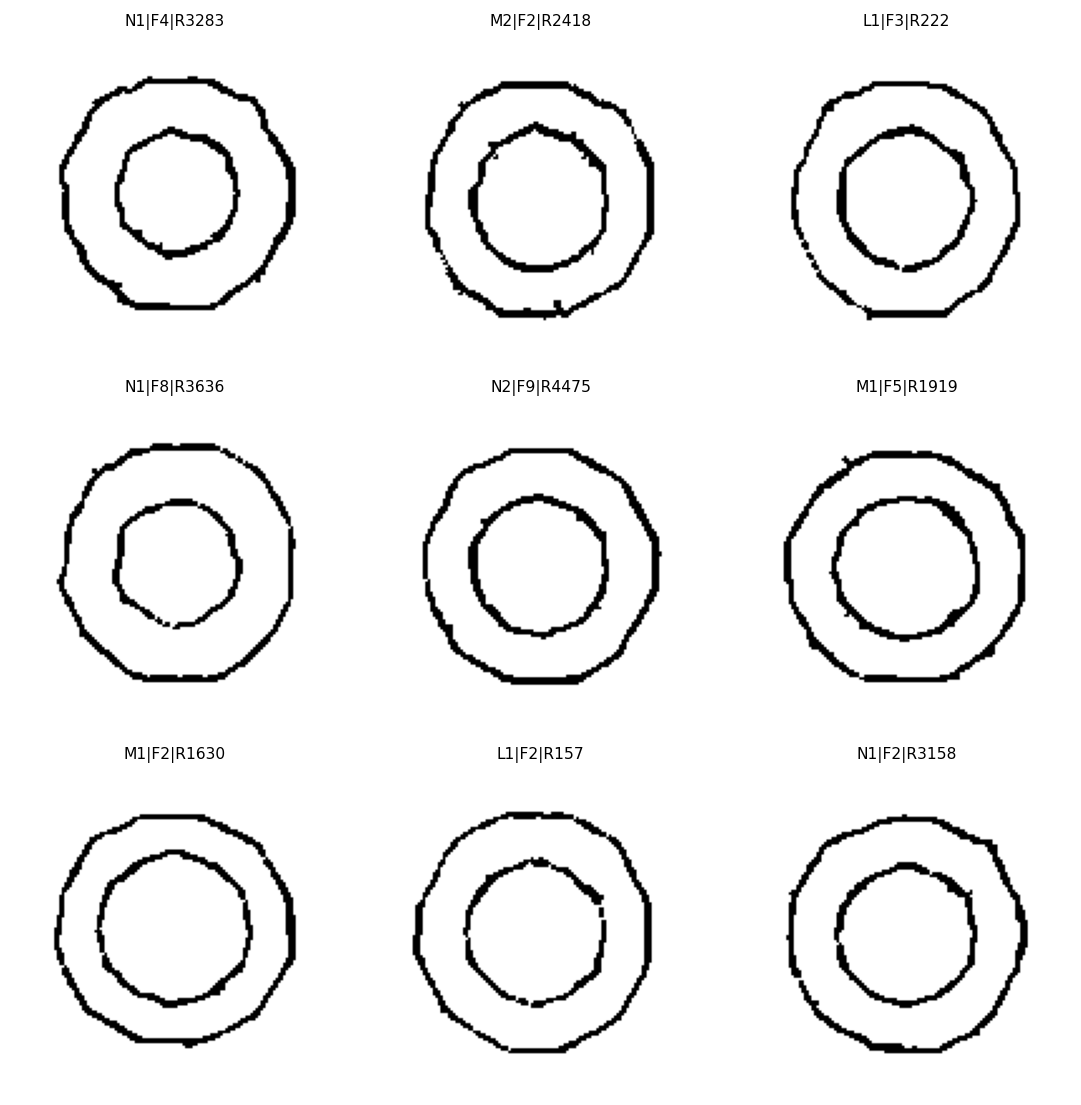

In [ ]:
# =========================
# Quick sanity check: visualize a few processed masks
# =========================

# Number of images to display (up to 9)
n_show = min(9, len(df))

# Select random row indices in a reproducible way
idxs = np.random.RandomState(SEED).choice(len(df), n_show, replace=False)

# Create a 3x3 grid of subplots
fig, axs = plt.subplots(3, 3, figsize=(8, 8))

# Loop over selected indices and corresponding subplot axes
for ax, i in zip(axs.flatten(), idxs):
    # Display the processed binary mask in grayscale
    ax.imshow(df["binary_proc"].iloc[i], cmap="gray")
    
    # Extract the MultiIndex values: sample_ID, field_ID, ring_ID
    s, f, r = df.index[i]
    
    # Add a compact title showing sample, field, and ring identifiers
    ax.set_title(f"{s}|F{f}|R{r}", fontsize=8)
    
    # Hide axis ticks and frame for cleaner visualization
    ax.axis("off")

# Adjust spacing between subplots
plt.tight_layout()

# Show the figure
plt.show()

In [ ]:
# =========================
# Dataset and DataLoaders for VAE training/validation
# =========================

class MaskDataset(Dataset):
    """
    PyTorch dataset for binary mask images.

    Parameters
    ----------
    masks : array-like
        Collection of preprocessed mask images.
    augment : bool
        Whether to apply random D4-style augmentation
        (rotations + horizontal/vertical flips).
    """
    
    def __init__(self, masks, augment=True):
        # Store the mask array/list
        self.masks = masks
        
        # Flag controlling whether augmentation is applied
        self.augment = augment

    def __len__(self):
        # Return the total number of masks in the dataset
        return len(self.masks)

    def __getitem__(self, idx):
        # Get one mask by index
        m = self.masks[idx]

        # Apply random D4-style augmentation if enabled
        if self.augment:
            # Random rotation by 0, 90, 180, or 270 degrees
            k = random.randint(0, 3)
            m = np.rot90(m, k)

            # Random left-right flip with 50% probability
            if random.random() > 0.5:
                m = np.fliplr(m)

            # Random up-down flip with 50% probability
            if random.random() > 0.5:
                m = np.flipud(m)

            # Ensure array memory is contiguous before converting to PyTorch tensor
            m = np.ascontiguousarray(m)

        # Convert to PyTorch tensor, add channel dimension, and cast to float
        # Output shape becomes [1, H, W]
        return torch.from_numpy(m).unsqueeze(0).float()


# Extract processed masks from the dataframe
masks_np = df["binary_proc"].values

# Create the full dataset
# Augmentation is controlled by the use_D4_augmentation flag
dataset = MaskDataset(masks_np, augment=use_D4_augmentation)

# Split dataset into training and validation subsets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# Perform a reproducible random split
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Use worker processes only when CUDA is available
# On CPU-only environments, num_workers=0 is often simpler/more stable
num_workers = 2 if torch.cuda.is_available() else 0

# Training DataLoader:
# - shuffle=True so batches are randomized each epoch
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

# Validation DataLoader:
# - shuffle=False because validation does not require random ordering
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

# Print dataset split sizes
print(f"Train={len(train_dataset)}, Val={len(val_dataset)}")

Train=4800, Val=1200


### Step 3 — Define the VAE and training protocol

We train a convolutional VAE that compresses each $128\times128$ edge map to a latent mean vector $\mu \in \mathbb{R}^{d_z}$ and reconstructs the input. The VAE is trained using a Bernoulli likelihood (binary cross-entropy reconstruction term) plus a KL regularization term (ELBO objective; $\beta=1$). Data augmentation uses D4 transforms (rotations and flips) to reduce sensitivity to orientation.

In [ ]:
# =========================
# Variational Autoencoder (VAE) model
# =========================

class VAE(nn.Module):
    """
    Convolutional variational autoencoder for binary mask images.

    Parameters
    ----------
    latent_dim : int
        Size of the latent representation.
    image_size : int
        Input image size (assumed square, e.g. 128 for 128x128 images).
    """

    def __init__(self, latent_dim, image_size=128):
        super().__init__()

        # Store key model settings
        self.latent_dim = latent_dim
        self.image_size = image_size

        # -------------------------
        # Encoder
        # -------------------------
        # Convolutional stack that progressively downsamples the image:
        # 128 -> 64 -> 32 -> 16 -> 8
        # while increasing the number of feature channels
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),    # 1x128x128   -> 32x64x64
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),   # 32x64x64    -> 64x32x32
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),  # 64x32x32    -> 128x16x16
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(), # 128x16x16   -> 256x8x8
            nn.Flatten()                             # flatten to a 1D feature vector
        )

        # Size of the flattened encoder output
        # For 128x128 input, this is 256 * 8 * 8
        flatten_size = 256 * (image_size // 16) * (image_size // 16)

        # Linear layers to predict the latent mean and log-variance
        self.fc_mu = nn.Linear(flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(flatten_size, latent_dim)

        # -------------------------
        # Decoder
        # -------------------------
        # First map the latent vector back to the flattened feature size
        self.decoder_input = nn.Linear(latent_dim, flatten_size)

        # Transposed-convolution stack that upsamples back to the original size:
        # 8 -> 16 -> 32 -> 64 -> 128
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(), # 256x8x8   -> 128x16x16
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),  # 128x16x16 -> 64x32x32
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),   # 64x32x32  -> 32x64x64
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid()  # 32x64x64  -> 1x128x128
        )

    def encode(self, x):
        """
        Encode the input image into latent mean and log-variance.
        """
        # Pass input through the encoder network
        h = self.encoder(x)

        # Compute latent mean
        mu = self.fc_mu(h)

        # Compute latent log-variance and clamp for numerical stability
        logvar = self.fc_logvar(h).clamp(min=-10, max=10)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Apply the reparameterization trick:
        z = mu + eps * std, where eps ~ N(0, I)
        """
        # Convert log-variance to standard deviation
        std = torch.exp(0.5 * logvar)

        # Sample Gaussian noise with the same shape
        eps = torch.randn_like(std)

        # Return a differentiable latent sample
        return mu + eps * std

    def decode(self, z):
        """
        Decode a latent vector back into an image.
        """
        # Map latent vector to flattened decoder input
        h = self.decoder_input(z)

        # Reshape into a feature map for transposed convolutions
        h = h.view(-1, 256, self.image_size // 16, self.image_size // 16)

        # Reconstruct the image
        return self.decoder(h)

    def forward(self, x):
        """
        Full VAE forward pass:
        encode -> sample latent vector -> decode
        """
        # Encode input into latent distribution parameters
        mu, logvar = self.encode(x)

        # Sample latent vector using the reparameterization trick
        z = self.reparameterize(mu, logvar)

        # Decode latent vector into reconstructed image
        xr = self.decode(z)

        return xr, mu, logvar

In [ ]:
# =========================
# Loss function and training helper functions
# =========================

def vae_loss_terms(recon, x, mu, logvar, beta=1.0):
    """
    Compute the VAE loss and its two main components.

    Parameters
    ----------
    recon : torch.Tensor
        Reconstructed output from the decoder.
    x : torch.Tensor
        Original input batch.
    mu : torch.Tensor
        Latent mean produced by the encoder.
    logvar : torch.Tensor
        Latent log-variance produced by the encoder.
    beta : float
        Weight applied to the KL-divergence term.

    Returns
    -------
    total : torch.Tensor
        Total VAE loss = reconstruction loss + beta * KL divergence.
    bce : torch.Tensor
        Binary cross-entropy reconstruction loss.
    kl : torch.Tensor
        KL-divergence regularization term.
    """
    
    # Reconstruction loss:
    # Binary cross-entropy summed over all pixels, then averaged over batch size
    bce = nn.functional.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)

    # KL-divergence between the learned latent distribution and a unit Gaussian prior
    # Also averaged over batch size
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    # Total beta-VAE objective
    total = bce + beta * kl

    return total, bce, kl


@torch.no_grad()
def estimate_active_dims(model, loader, latent_dim, kl_threshold=0.01):
    """
    Estimate how many latent dimensions are 'active' based on their average KL usage.

    A latent dimension is counted as active if its mean KL contribution exceeds
    the specified threshold.

    Parameters
    ----------
    model : VAE
        Trained VAE model.
    loader : DataLoader
        DataLoader used to evaluate latent usage.
    latent_dim : int
        Total number of latent dimensions.
    kl_threshold : float
        Threshold above which a latent dimension is considered active.

    Returns
    -------
    kl_mean : np.ndarray
        Mean KL contribution for each latent dimension.
    active : int
        Number of active latent dimensions.
    """
    
    # Set model to evaluation mode
    model.eval()

    # Accumulate KL contribution for each latent dimension
    kl_sum = torch.zeros(latent_dim, device=device)

    # Count total number of samples processed
    n = 0

    # Loop through batches without tracking gradients
    for x in loader:
        x = x.to(device)

        # Encode input into latent distribution parameters
        mu, logvar = model.encode(x)

        # Per-sample, per-dimension KL contribution
        # Shape: [batch_size, latent_dim]
        kl_per_dim = 0.5 * (mu.pow(2) + logvar.exp() - 1.0 - logvar)

        # Sum across the batch and accumulate
        kl_sum += kl_per_dim.sum(dim=0)

        # Update total sample count
        n += x.size(0)

    # Average KL contribution per dimension across all samples
    kl_mean = (kl_sum / max(n, 1)).detach().cpu().numpy()

    # Count dimensions whose average KL exceeds the activity threshold
    active = int(np.sum(kl_mean > kl_threshold))

    return kl_mean, active


def train_vae_one(latent_dim):
    """
    Train one VAE model for a given latent dimension.

    Parameters
    ----------
    latent_dim : int
        Size of the latent space for this training run.

    Returns
    -------
    model : VAE
        Trained model with the best validation state restored.
    hist : dict
        Training history containing validation losses per epoch.
    best_val : float
        Best validation loss achieved during training.
    """
    
    # Initialize model and move it to CPU/GPU
    model = VAE(latent_dim, image_size=image_size).to(device)

    # Adam optimizer
    opt = optim.Adam(model.parameters(), lr=learning_rate)

    # Track best model state for early stopping
    best_state = None
    best_val = float("inf")
    patience_ctr = 0

    # Store training history
    hist = {
        "train_total": [],
        "val_total": [],
        "val_bce": [],
        "val_kl": []
    }

    # Main training loop
    for epoch in range(epochs):
        model.train()

        # -------------------------
        # Training pass
        # -------------------------
        for x in train_loader:
            x = x.to(device)

            # Forward pass
            recon, mu, logvar = model(x)

            # Compute VAE loss
            total, bce, kl = vae_loss_terms(recon, x, mu, logvar, beta=beta_kl)

            # Backpropagation and optimizer step
            opt.zero_grad()
            total.backward()
            opt.step()

        # -------------------------
        # Validation pass
        # -------------------------
        model.eval()
        va_total = 0.0
        va_bce = 0.0
        va_kl = 0.0

        with torch.no_grad():
            for x in val_loader:
                x = x.to(device)

                # Forward pass
                recon, mu, logvar = model(x)

                # Compute validation loss terms
                total, bce, kl = vae_loss_terms(recon, x, mu, logvar, beta=beta_kl)

                # Accumulate batch losses
                va_total += total.item()
                va_bce += bce.item()
                va_kl += kl.item()

        # Average validation losses across all validation batches
        va_total /= len(val_loader)
        va_bce   /= len(val_loader)
        va_kl    /= len(val_loader)

        # Save metrics to history
        # train_total is left as NaN here because training loss is not explicitly aggregated
        hist["train_total"].append(np.nan)
        hist["val_total"].append(va_total)
        hist["val_bce"].append(va_bce)
        hist["val_kl"].append(va_kl)

        # -------------------------
        # Early stopping
        # -------------------------
        # Save model only if validation loss improves by more than min_delta
        if (best_val - va_total) > min_delta:
            best_val = va_total

            # Store a CPU copy of the best weights
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

            # Reset patience counter
            patience_ctr = 0
        else:
            # No meaningful improvement this epoch
            patience_ctr += 1

            # Stop training if patience limit is reached
            if patience_ctr >= patience:
                break

    # Restore the best validation model state
    if best_state is not None:
        model.load_state_dict(best_state)

    # Switch to evaluation mode before returning
    model.eval()

    return model, hist, best_val

In [ ]:
# =========================
# Encode latent means (mu) for all masks
# Optionally use test-time augmentation (TTA) based on D4-style transforms
# =========================

@torch.no_grad()
def encode_all_mu(model, masks_np, device=None, use_tta=True):
    """
    Encode latent mean vectors (mu) for all input masks.

    Parameters
    ----------
    model : VAE
        Trained VAE model used for encoding.
    masks_np : iterable
        Iterable of NumPy arrays with shape (H, W), expected to be in [0, 1].
    device : torch.device or None
        Device on which encoding is performed. If None, uses the model's device.
    use_tta : bool
        Whether to use test-time augmentation by averaging latent means
        across rotated and flipped versions of each mask.

    Returns
    -------
    np.ndarray
        Array of latent mean vectors with shape [N, D],
        where N is the number of masks and D is the latent dimension.
    """

    # Set model to evaluation mode
    model.eval()

    # If no device is given, infer it from the model parameters
    if device is None:
        device = next(model.parameters()).device

    # List to collect latent mean vectors for all masks
    Z = []

    # Loop over all processed masks
    for m in tqdm(masks_np, desc=f"Encoding mu (D={model.latent_dim})"):
        # Convert one mask to a tensor and add:
        # - batch dimension
        # - channel dimension
        # Final shape: [1, 1, H, W]
        x = torch.from_numpy(m).unsqueeze(0).unsqueeze(0).float().to(device)

        # If test-time augmentation is disabled, encode directly
        if not use_tta:
            mu, _ = model.encode(x)
            Z.append(mu.squeeze(0).cpu().numpy())
            continue

        # -------------------------
        # D4-style test-time augmentation
        # -------------------------
        # For each of 4 rotations, also encode:
        # - the rotated image
        # - its left-right flipped version
        # - its up-down flipped version
        # Total = 12 variants
        mus = []

        for k in range(4):
            # Rotate by k * 90 degrees
            rot = torch.rot90(x, k, dims=(2, 3))

            # Encode rotated version
            mu, _ = model.encode(rot)
            mus.append(mu)

            # Encode left-right flipped rotated version
            mu, _ = model.encode(torch.fliplr(rot))
            mus.append(mu)

            # Encode up-down flipped rotated version
            mu, _ = model.encode(torch.flipud(rot))
            mus.append(mu)

        # Average latent means across all augmented versions
        mu = torch.stack(mus, dim=0).mean(dim=0)

        # Store result as a NumPy array
        Z.append(mu.squeeze(0).cpu().numpy())

    # Stack all latent vectors into a single array of shape [N, D]
    return np.vstack(Z)

In [ ]:
# =========================
# Downstream prediction: measure the added value of latent vectors via Delta R^2
# using GroupKFold grouped by sample_ID + field_ID
# =========================

def downstream_delta_r2(df_in, latent_vectors, y_col, param_cols, n_splits=5, ridge_alpha=1.0):
    """
    Compare predictive performance with and without latent vectors.

    Baseline model:
        uses only the nominal process/geometry parameters in param_cols

    Full model:
        uses nominal parameters + VAE latent vectors

    The function evaluates both models using GroupKFold, where each group is
    defined by the combination of sample_ID and field_ID, so that rings from
    the same sample-field group stay together in either train or test.

    Parameters
    ----------
    df_in : pd.DataFrame
        Input dataframe containing metadata and target values.
    latent_vectors : np.ndarray
        Latent representation array of shape [N, D], where N is the number of rows
        in df_in and D is the latent dimension.
    y_col : str
        Name of the target column to predict.
    param_cols : list of str
        List of nominal parameter columns used in the baseline model.
    n_splits : int
        Number of GroupKFold splits.
    ridge_alpha : float
        Regularization strength for Ridge regression.

    Returns
    -------
    r2b : np.ndarray
        Baseline-model R^2 values across folds.
    r2f : np.ndarray
        Full-model R^2 values across folds.
    dR2 : np.ndarray
        Fold-wise improvement in R^2 after adding the latent vectors,
        computed as (R^2_full - R^2_base).
    """

    # Extract nominal parameter matrix as float32
    Xp = df_in[param_cols].values.astype(np.float32)

    # Extract target values as float32
    y = df_in[y_col].values.astype(np.float32)

    # Ensure latent vectors are also float32
    Z = latent_vectors.astype(np.float32)

    # Build grouping labels using sample_ID and field_ID together
    # This ensures all rings from the same sample-field combination
    # stay in the same fold
    idx = df_in.reset_index()[["sample_ID", "field_ID"]].astype(str)
    groups = (idx["sample_ID"] + "_" + idx["field_ID"]).values

    # Baseline pipeline:
    # standardize inputs, then fit Ridge regression on nominal parameters only
    base = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=ridge_alpha))
    ])

    # Full pipeline:
    # standardize inputs, then fit Ridge regression on nominal parameters + latents
    full = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=ridge_alpha))
    ])

    # Group-aware cross-validation splitter
    gkf = GroupKFold(n_splits=n_splits)

    # Lists to store fold-wise results
    r2b, r2f, dR2 = [], [], []

    # Loop over train/test splits
    for tr, te in gkf.split(Xp, y, groups):
        # -------------------------
        # Baseline model: parameters only
        # -------------------------
        base.fit(Xp[tr], y[tr])
        r2_base = r2_score(y[te], base.predict(Xp[te]))

        # -------------------------
        # Full model: parameters + latent vectors
        # -------------------------
        Xfull_tr = np.hstack([Xp[tr], Z[tr]])
        Xfull_te = np.hstack([Xp[te], Z[te]])

        full.fit(Xfull_tr, y[tr])
        r2_full = r2_score(y[te], full.predict(Xfull_te))

        # Store fold-wise scores and improvement
        r2b.append(r2_base)
        r2f.append(r2_full)
        dR2.append(r2_full - r2_base)

    # Return results as NumPy arrays
    return np.array(r2b), np.array(r2f), np.array(dR2)


### Latent dimensionality ablation (selecting $d_z$ using downstream $\Delta R^2$)

Our goal is not only to reconstruct the binary edge maps, but to learn a morphology embedding that adds *useful* information for predicting the corrected lasing threshold beyond the measured growth and nominal geometry parameters. We therefore treat the latent dimensionality $d_z$ as a hyperparameter and choose it based on downstream predictive benefit.

**What we do (for each $d_z \in \{4,8,16,32,64\}$).**
1. Train a VAE with fixed architecture and training settings (only $d_z$ changes).
2. Encode each ring to its latent mean vector $\mu \in \mathbb{R}^{d_z}$.
3. Fit two ridge regression models under leakage-safe cross-validation:
   - **Baseline:** measured parameters only (growth + nominal geometry)
   - **Augmented:** measured parameters + latent features $\mu$
4. Compute the gain in predictive performance:
   $$
   \Delta R^2 = R^2_{\mathrm{aug}} - R^2_{\mathrm{base}} .
   $$

**Leakage control.** We use GroupKFold cross-validation grouped by $(\mathrm{sample\_ID}, \mathrm{field\_ID})$ so that rings from the same field are never split across train/test folds.




==================== latent_dim=4 ====================


Train VAE (D=4):   0%|          | 0/200 [00:00<?, ?it/s]

[D=4] epoch   1/200 | val 2293.0629 (bce 2285.3541, kl 7.7088) | pat 0/15
[D=4] epoch  10/200 | val 1290.6904 (bce 1275.9568, kl 14.7335) | pat 0/15
[D=4] epoch  20/200 | val 1274.0003 (bce 1258.8895, kl 15.1107) | pat 5/15
[D=4] epoch  30/200 | val 1263.6538 (bce 1248.5218, kl 15.1319) | pat 0/15
[D=4] epoch  40/200 | val 1251.1964 (bce 1235.1574, kl 16.0390) | pat 0/15
[D=4] epoch  50/200 | val 1258.6685 (bce 1242.8452, kl 15.8233) | pat 9/15
[D=4] epoch  60/200 | val 1250.2900 (bce 1234.5138, kl 15.7762) | pat 5/15
[D=4] epoch  70/200 | val 1250.4593 (bce 1235.1908, kl 15.2684) | pat 6/15
[D=4] epoch  80/200 | val 1252.7895 (bce 1237.1275, kl 15.6620) | pat 7/15
[D=4] epoch  90/200 | val 1246.5097 (bce 1231.2797, kl 15.2300) | pat 2/15
[D=4] epoch 100/200 | val 1249.7105 (bce 1234.5644, kl 15.1461) | pat 8/15
[D=4] epoch 110/200 | val 1241.4899 (bce 1225.7585, kl 15.7314) | pat 3/15
[D=4] epoch 120/200 | val 1252.2618 (bce 1236.6282, kl 15.6336) | pat 13/15
[D=4] early stop at epoch

Encoding μ (D=4):   0%|          | 0/6000 [00:00<?, ?it/s]


==================== latent_dim=8 ====================


...

Train VAE (D=64):   0%|          | 0/200 [00:00<?, ?it/s]

[D=64] epoch   1/200 | val 2237.8538 (bce 2221.0249, kl 16.8289) | pat 0/15
[D=64] epoch  10/200 | val 866.9003 (bce 757.9195, kl 108.9807) | pat 0/15
[D=64] epoch  20/200 | val 776.6243 (bce 657.2736, kl 119.3506) | pat 0/15
[D=64] epoch  30/200 | val 735.4244 (bce 615.1789, kl 120.2454) | pat 0/15
[D=64] epoch  40/200 | val 722.5806 (bce 595.7862, kl 126.7944) | pat 0/15
[D=64] epoch  50/200 | val 706.7877 (bce 583.2472, kl 123.5406) | pat 3/15
[D=64] epoch  60/200 | val 708.7377 (bce 589.8519, kl 118.8859) | pat 2/15
[D=64] epoch  70/200 | val 697.6628 (bce 574.5515, kl 123.1113) | pat 0/15
[D=64] epoch  80/200 | val 697.7499 (bce 575.9011, kl 121.8488) | pat 5/15
[D=64] epoch  90/200 | val 704.0731 (bce 580.4986, kl 123.5746) | pat 5/15
[D=64] early stop at epoch 99. best_val=691.8073


Encoding μ (D=64):   0%|          | 0/6000 [00:00<?, ?it/s]

,latent_dim,best_val_total(BCE+βKL),val_bce_last,val_kl_last,active_dims(KL>0.01),R2_base_mean,R2_full_mean,dR2_mean,dR2_std
0,4,1239.144292,1233.376951,15.500308,4,0.344523,0.368448,0.023925,0.011252
1,8,1042.581412,1021.203228,27.748583,8,0.344523,0.377371,0.032848,0.016234
2,16,908.839247,871.500828,47.538041,16,0.344523,0.377019,0.032496,0.021443
3,32,794.426774,731.516897,75.632037,32,0.344523,0.386032,0.041509,0.028403
4,64,691.807314,574.469713,119.891048,64,0.344523,0.388999,0.044477,0.025021


Saved: ./latent_dim_sweep_20260303_110401/latent_dim_sweep_results.csv


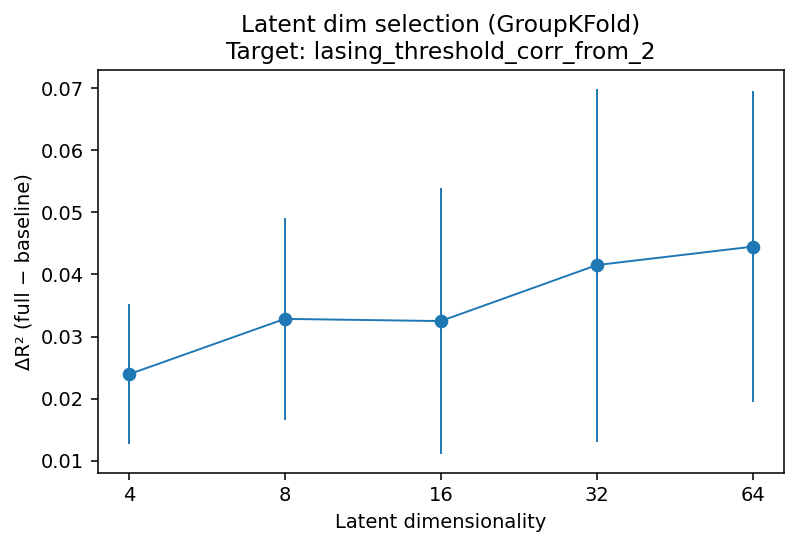

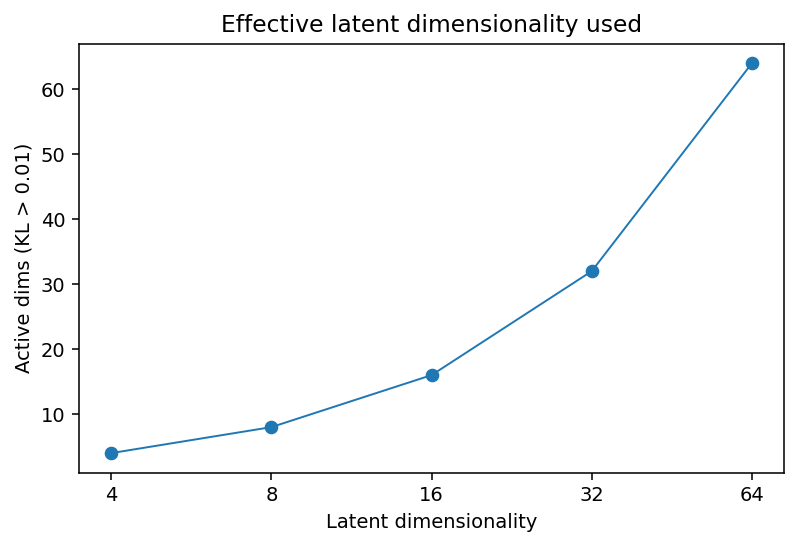

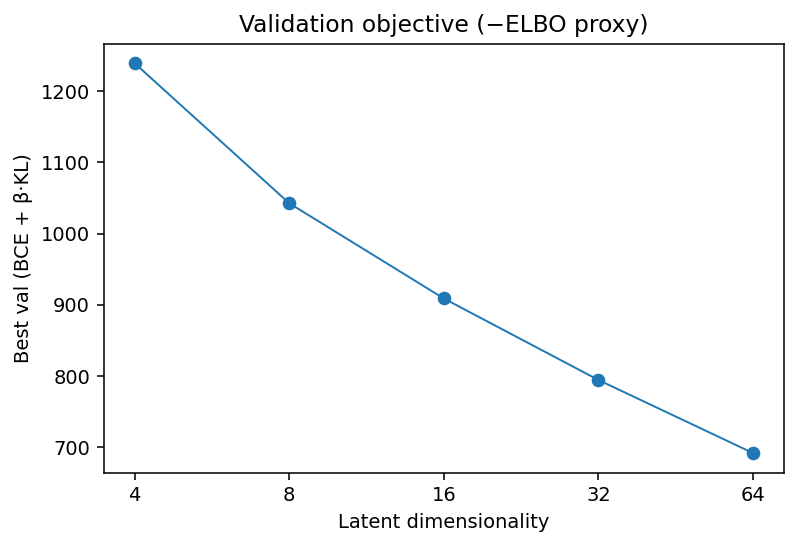


AUTO-CONCLUSION
- Best mean ΔR² = 0.0445 at D=64
- 1-SE threshold = 0.0333
- Chosen latent dim = smallest D with mean ΔR² >= threshold → D=32
Saved: ./latent_dim_sweep_20260303_110401/selection_summary.json


In [ ]:
# ----------------------------
# Trainer
# ----------------------------
# Trains one VAE while:
# - showing a progress bar over epochs
# - printing only every `print_every` epochs
# - using early stopping based on validation loss
def train_vae_one_quiet(latent_dim,
                        train_loader, val_loader,
                        image_size=128,
                        lr=1e-3,
                        beta_kl=1.0,
                        epochs=200,
                        patience=15,
                        min_delta=1e-4,
                        device="cuda",
                        print_every=10):
    # Initialize a VAE with the chosen latent dimension
    model = VAE(latent_dim, image_size=image_size).to(device)

    # Use Adam optimizer
    opt = optim.Adam(model.parameters(), lr=lr)

    # Track the best validation score and corresponding model state
    best_state = None
    best_val = float("inf")
    patience_ctr = 0

    # Store training and validation histories
    hist = {
        "train_total": [], "train_bce": [], "train_kl": [],
        "val_total": [],   "val_bce": [],   "val_kl": []
    }

    # Progress bar over epochs
    pbar = tqdm(range(epochs), desc=f"Train VAE (D={latent_dim})", leave=True)
    for epoch in pbar:
        # -------------------------
        # Training phase
        # -------------------------
        model.train()
        tr_total = tr_bce = tr_kl = 0.0

        for x in train_loader:
            # Move batch to device
            x = x.to(device)

            # Forward pass through VAE
            recon, mu, logvar = model(x)

            # Compute total loss, reconstruction loss, and KL term
            total, bce, kl = vae_loss_terms(recon, x, mu, logvar, beta=beta_kl)

            # Backpropagation and optimizer step
            opt.zero_grad()
            total.backward()
            opt.step()

            # Accumulate batch losses
            tr_total += total.item()
            tr_bce   += bce.item()
            tr_kl    += kl.item()

        # Average training losses across batches
        tr_total /= len(train_loader)
        tr_bce   /= len(train_loader)
        tr_kl    /= len(train_loader)

        # -------------------------
        # Validation phase
        # -------------------------
        model.eval()
        va_total = va_bce = va_kl = 0.0

        with torch.no_grad():
            for x in val_loader:
                # Move validation batch to device
                x = x.to(device)

                # Forward pass
                recon, mu, logvar = model(x)

                # Compute validation loss terms
                total, bce, kl = vae_loss_terms(recon, x, mu, logvar, beta=beta_kl)

                # Accumulate losses
                va_total += total.item()
                va_bce   += bce.item()
                va_kl    += kl.item()

        # Average validation losses across batches
        va_total /= len(val_loader)
        va_bce   /= len(val_loader)
        va_kl    /= len(val_loader)

        # Save this epoch's metrics
        hist["train_total"].append(tr_total)
        hist["train_bce"].append(tr_bce)
        hist["train_kl"].append(tr_kl)
        hist["val_total"].append(va_total)
        hist["val_bce"].append(va_bce)
        hist["val_kl"].append(va_kl)

        # Update progress bar display with current validation metrics
        pbar.set_postfix({
            "val": f"{va_total:.3f}",
            "bce": f"{va_bce:.3f}",
            "kl":  f"{va_kl:.3f}",
            "pat": f"{patience_ctr}/{patience}"
        })

        # Print only occasionally to keep notebook output compact
        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(f"[D={latent_dim}] epoch {epoch+1:>3}/{epochs} | "
                  f"val {va_total:.4f} (bce {va_bce:.4f}, kl {va_kl:.4f}) | "
                  f"pat {patience_ctr}/{patience}")

        # -------------------------
        # Early stopping check
        # -------------------------
        # Save the model only if validation loss improves by more than min_delta
        if (best_val - va_total) > min_delta:
            best_val = va_total
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"[D={latent_dim}] early stop at epoch {epoch+1}. best_val={best_val:.4f}")
                break

    # Restore the best validation model weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # Put model in evaluation mode before returning
    model.eval()

    return model, hist, float(best_val)

# ----------------------------
# Sweep over latent dimensions and evaluate each model
# ----------------------------

# List to store one summary row per latent dimension
results = []

# Dictionary to store full training histories keyed by latent dimension
histories = {}

for D in latent_dims_to_try:
    print(f"\n==================== latent_dim={D} ====================")

    # Train one VAE for this latent dimension
    model_D, hist_D, best_val = train_vae_one_quiet(
        latent_dim=D,
        train_loader=train_loader,
        val_loader=val_loader,
        image_size=image_size,
        lr=learning_rate,
        beta_kl=beta_kl,
        epochs=epochs,
        patience=patience,
        min_delta=min_delta,
        device=device,
        print_every=10  # print every 10 epochs
    )

    # Save history for later inspection if needed
    histories[D] = hist_D

    # Estimate how many latent dimensions are actively being used
    # based on average KL contribution
    kl_mean, active = estimate_active_dims(model_D, val_loader, D, device=device, kl_threshold=0.01)

    # Encode the latent mean vector mu for every ring in the dataset
    Z = encode_all_mu(model_D, masks_np, device=device, use_tta=use_TTA_encoding)

    # Measure downstream predictive gain from adding latent vectors
    # using grouped cross-validation
    r2b, r2f, dR2 = downstream_delta_r2(
        df_in=df,
        latent_vectors=Z,
        y_col=y_col,
        param_cols=param_cols,
        n_splits=n_splits,
        ridge_alpha=ridge_alpha
    )

    # Save summary metrics for this latent dimension
    results.append({
        "latent_dim": D,
        "best_val_total(BCE+βKL)": float(best_val),
        "val_bce_last": float(hist_D["val_bce"][-1]),
        "val_kl_last": float(hist_D["val_kl"][-1]),
        "active_dims(KL>0.01)": int(active),
        "R2_base_mean": float(r2b.mean()),
        "R2_full_mean": float(r2f.mean()),
        "dR2_mean": float(dR2.mean()),
        "dR2_std": float(dR2.std(ddof=1)) if len(dR2) > 1 else 0.0,
    })

    # Free memory between sweep iterations
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ----------------------------
# Create results table and save as CSV
# ----------------------------

# Convert results list to DataFrame and sort by latent dimension
res_df = pd.DataFrame(results).sort_values("latent_dim").reset_index(drop=True)

# Display the results table in the notebook
display(res_df)

# Save the results table to disk
csv_path = os.path.join(save_dir, "latent_dim_sweep_results.csv")
res_df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

# ----------------------------
# Prepare arrays for plotting
# ----------------------------
Ds   = res_df["latent_dim"].values
dR2m = res_df["dR2_mean"].values
dR2s = res_df["dR2_std"].values
act  = res_df["active_dims(KL>0.01)"].values
valT = res_df["best_val_total(BCE+βKL)"].values

# ----------------------------
# Plot 1: Delta R^2 vs latent dimension
# ----------------------------
plt.figure(figsize=(5.8, 4))
plt.errorbar(Ds, dR2m, yerr=dR2s, marker="o", linewidth=1)
plt.xscale("log", base=2)
plt.xticks(Ds, Ds)
plt.xlabel("Latent dimensionality")
plt.ylabel("ΔR² (full − baseline)")
plt.title(f"Latent dim selection (GroupKFold)\nTarget: {y_col}")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "deltaR2_vs_dim.png"))
plt.show()

# ----------------------------
# Plot 2: Number of active latent dimensions vs latent dimension
# ----------------------------
plt.figure(figsize=(5.8, 4))
plt.plot(Ds, act, marker="o", linewidth=1)
plt.xscale("log", base=2)
plt.xticks(Ds, Ds)
plt.xlabel("Latent dimensionality")
plt.ylabel("Active dims (KL > 0.01)")
plt.title("Effective latent dimensionality used")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "active_dims_vs_dim.png"))
plt.show()

# ----------------------------
# Plot 3: Best validation objective vs latent dimension
# ----------------------------
plt.figure(figsize=(5.8, 4))
plt.plot(Ds, valT, marker="o", linewidth=1)
plt.xscale("log", base=2)
plt.xticks(Ds, Ds)
plt.xlabel("Latent dimensionality")
plt.ylabel("Best val (BCE + β·KL)")
plt.title("Validation objective (−ELBO proxy)")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "val_objective_vs_dim.png"))
plt.show()

# ----------------------------
# Automatic latent-dimension choice using the 1-standard-error rule
# ----------------------------

# Find the latent dimension with the highest mean Delta R^2
best_idx = int(np.argmax(dR2m))
best_mean = float(dR2m[best_idx])

# Estimate the standard error of Delta R^2 at the best point
best_se = float(dR2s[best_idx] / np.sqrt(n_splits)) if n_splits > 1 else 0.0

# Define the 1-SE threshold:
# choose the smallest latent dimension whose mean Delta R^2
# is within one standard error of the best mean
threshold = best_mean - best_se

# Find all latent dimensions that meet this threshold
eligible = Ds[dR2m >= threshold]

# Choose the smallest eligible latent dimension
chosen = int(np.min(eligible))

# Print the automatic conclusion
print("\nAUTO-CONCLUSION")
print(f"- Best mean ΔR² = {best_mean:.4f} at D={int(Ds[best_idx])}")
print(f"- 1-SE threshold = {threshold:.4f}")
print(f"- Chosen latent dim = smallest D with mean ΔR² >= threshold → D={chosen}")

# ----------------------------
# Save selection summary as JSON
# ----------------------------
summary = {
    "chosen_latent_dim": chosen,
    "best_dim": int(Ds[best_idx]),
    "best_mean_dR2": best_mean,
    "best_se_dR2": best_se,
    "threshold_1se": threshold,
    "y_col": y_col,
    "param_cols": param_cols,
    "latent_dims_tried": latent_dims_to_try,
    "beta_kl": beta_kl,
    "image_size": image_size,
    "n_splits": n_splits,
    "ridge_alpha": ridge_alpha
}

json_path = os.path.join(save_dir, "selection_summary.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", json_path)

**Outcome.** The downstream gain $\Delta R^2$ increases with $d_z$ and shows diminishing returns beyond $d_z=32$ (see the $\Delta R^2$ plot).  
Although $d_z=64$ yields the highest mean $\Delta R^2$, we apply a **one–standard error (1-SE) rule** and choose the *smallest* $d_z$ whose mean $\Delta R^2$ is within one standard error of the best model. This selects **$d_z = 32$** as the minimal latent size with near-optimal downstream performance.

**Supporting diagnostics.** Alongside $\Delta R^2$, we report (i) the validation objective (BCE + $\beta$ $\cdot$ KL) and (ii) the number of active latent dimensions (KL $>$ 0.01). These confirm that larger $d_z$ improves reconstruction/ELBO and that the selected model uses its latent capacity, but the final choice is driven by downstream $\Delta R^2$.

Training dynamics for the selected model ($d_z=32$)

We visualize training and validation curves (total loss, BCE, and KL) to confirm stable optimization, absence of divergence, and non-collapsed latent usage.

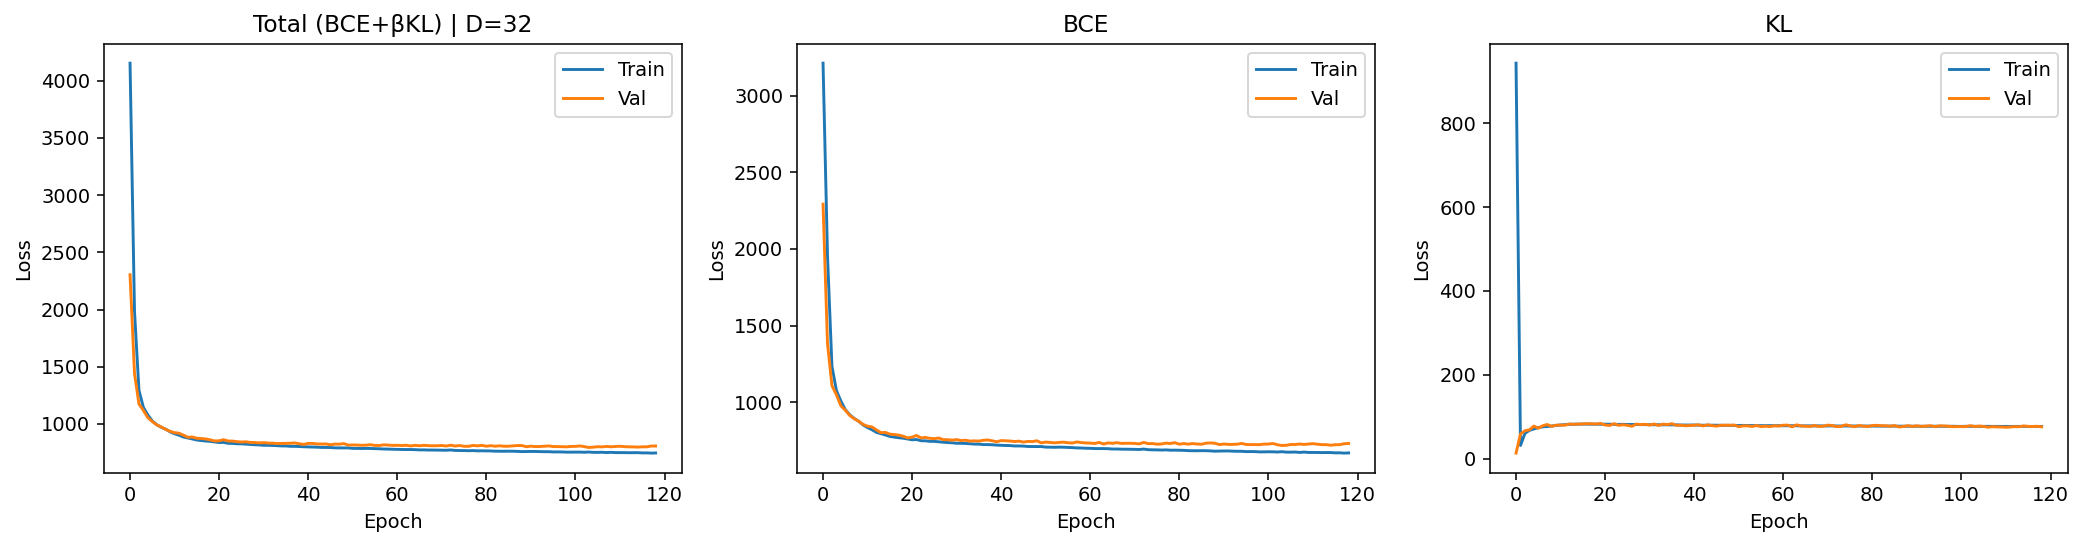

Saved: ./latent_dim_sweep_20260303_110401/training_curves_chosen_D32.png


In [ ]:
# =========================
# Plot training curves for the automatically chosen latent dimension
# =========================

# Use the latent dimension selected earlier by the 1-SE rule
D = chosen

# Retrieve the stored training history for the chosen latent dimension
hist = histories[D]

# Create a figure with three side-by-side subplots:
# 1. total loss
# 2. reconstruction BCE loss
# 3. KL-divergence loss
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# -------------------------
# Subplot 1: total loss = BCE + beta * KL
# -------------------------
axs[0].plot(hist["train_total"], label="Train")
axs[0].plot(hist["val_total"], label="Val")
axs[0].set_title(f"Total (BCE+βKL) | D={D}")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

# -------------------------
# Subplot 2: reconstruction loss (BCE)
# -------------------------
axs[1].plot(hist["train_bce"], label="Train")
axs[1].plot(hist["val_bce"], label="Val")
axs[1].set_title("BCE")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].legend()

# -------------------------
# Subplot 3: KL-divergence term
# -------------------------
axs[2].plot(hist["train_kl"], label="Train")
axs[2].plot(hist["val_kl"], label="Val")
axs[2].set_title("KL")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("Loss")
axs[2].legend()

# Adjust subplot spacing for a cleaner layout
plt.tight_layout()

# Save the figure for later use
plt.savefig(os.path.join(save_dir, f"training_curves_chosen_D{D}.png"))

# Display the figure in the notebook
plt.show()

# Print the saved file path
print("Saved:", os.path.join(save_dir, f"training_curves_chosen_D{D}.png"))

**Outcome.** Training and validation losses decrease smoothly and plateau without divergence. The KL term remains non-zero, indicating that the latent space is actively used (no posterior collapse).


### Qualitative reconstruction check

We compare representative original edge maps to their reconstructions for the selected model. This verifies that the VAE preserves the salient morphological features (inner and outer boundaries) while acting as a compact descriptor.

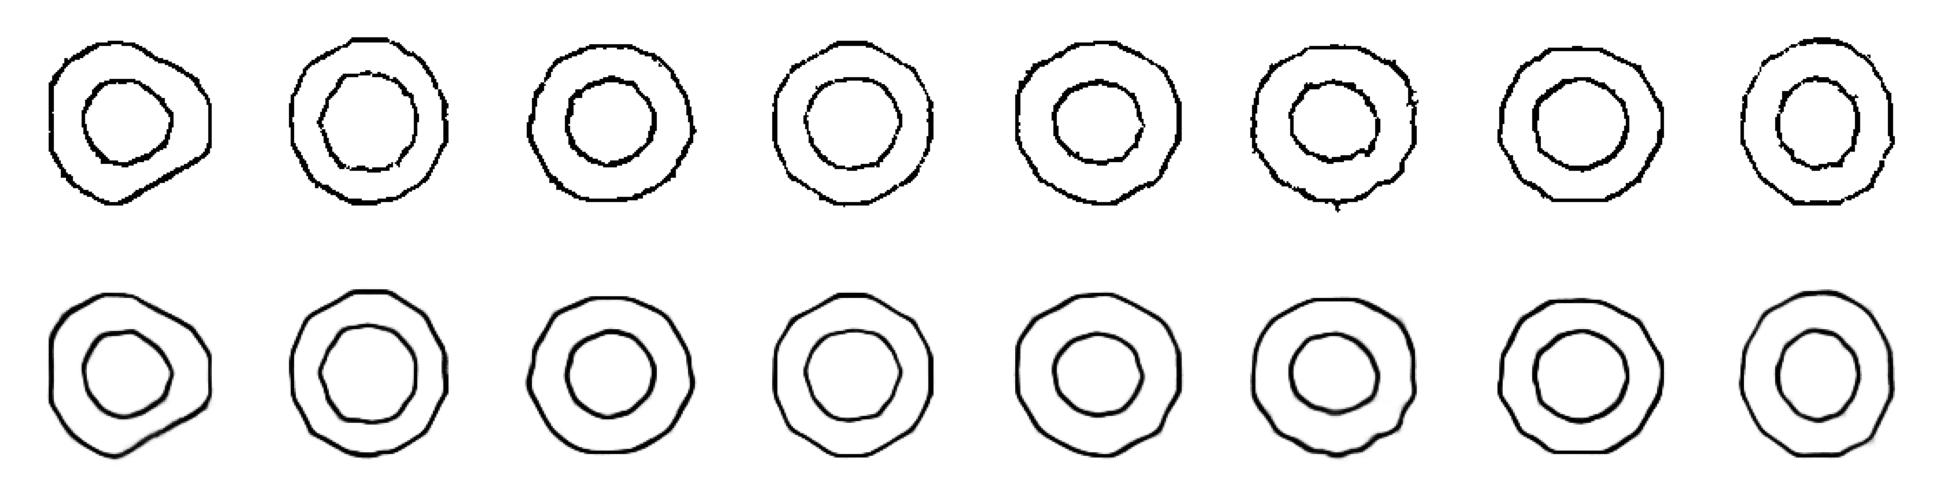

In [ ]:
# =========================
# Quick qualitative reconstruction check on the validation set
# =========================

# Use the currently selected/trained model
# Replace with a specifically loaded chosen model if needed
model = model_D
model.eval()

# Take one batch from the validation loader and keep the first 8 images
x = next(iter(val_loader)).to(device)[:8]

# Run the model in inference mode to get reconstructions
with torch.no_grad():
    recon, _, _ = model(x)

# Create a figure with:
# - top row = original input masks
# - bottom row = reconstructed masks
fig, axs = plt.subplots(2, 8, figsize=(14, 4))

for i in range(8):
    # Show original validation image
    axs[0, i].imshow(x[i, 0].cpu().numpy(), cmap="gray")
    axs[0, i].axis("off")

    # Show reconstructed image from the VAE
    axs[1, i].imshow(recon[i, 0].cpu().numpy(), cmap="gray")
    axs[1, i].axis("off")

# Add row labels to the first column
axs[0, 0].set_ylabel("Orig")
axs[1, 0].set_ylabel("Recon")

# Adjust spacing for cleaner layout
plt.tight_layout()

# Display the comparison figure
plt.show()

**Outcome.** Reconstructions preserve the key ring boundaries and main shape variations. Minor smoothing of high-frequency edge noise is expected and desirable for a compact morphology representation.

### Quantitative reconstruction overlap metrics


As a quantitative sanity check on how well the VAE reconstructs the binary edge maps, we compute three simple overlap metrics between the original mask and the reconstructed mask (after thresholding the reconstruction at 0.5):

- **IoU (Intersection over Union, also called the Jaccard index):** the fraction of pixels that overlap relative to the total area covered by either mask $\,|A\cap B|/|A\cup B|$.
- **Dice (Dice similarity coefficient / Sørensen–Dice):** a closely related overlap score $2|A\cap B|/(|A|+|B|)$, which is often slightly less sensitive than IoU for thin features.
- **Pixel accuracy:** the fraction of pixels that match exactly. (For sparse edge maps, pixel accuracy can be high even when small edge mismatches occur, so IoU/Dice are more informative.)

We report the distributions of these metrics on the validation set to confirm that reconstructions preserve the key ring boundaries.

No in-memory model found for D=32. Retraining D=32 for evaluation...


Train VAE (D=32):   0%|          | 0/200 [00:00<?, ?it/s]

[D=32] epoch   1/200 | val 2311.5427 (bce 2298.2011, kl 13.3415) | pat 0/15
[D=32] epoch  50/200 | val 811.2809 (bce 732.0759, kl 79.2050) | pat 1/15
[D=32] early stop at epoch 83. best_val=797.4213
Recon metrics on VAL (D=32):
  IoU:  mean=0.9806,  std=0.0068
  Dice: mean=0.9902, std=0.0036
  Acc:  mean=0.9818,  std=0.0065


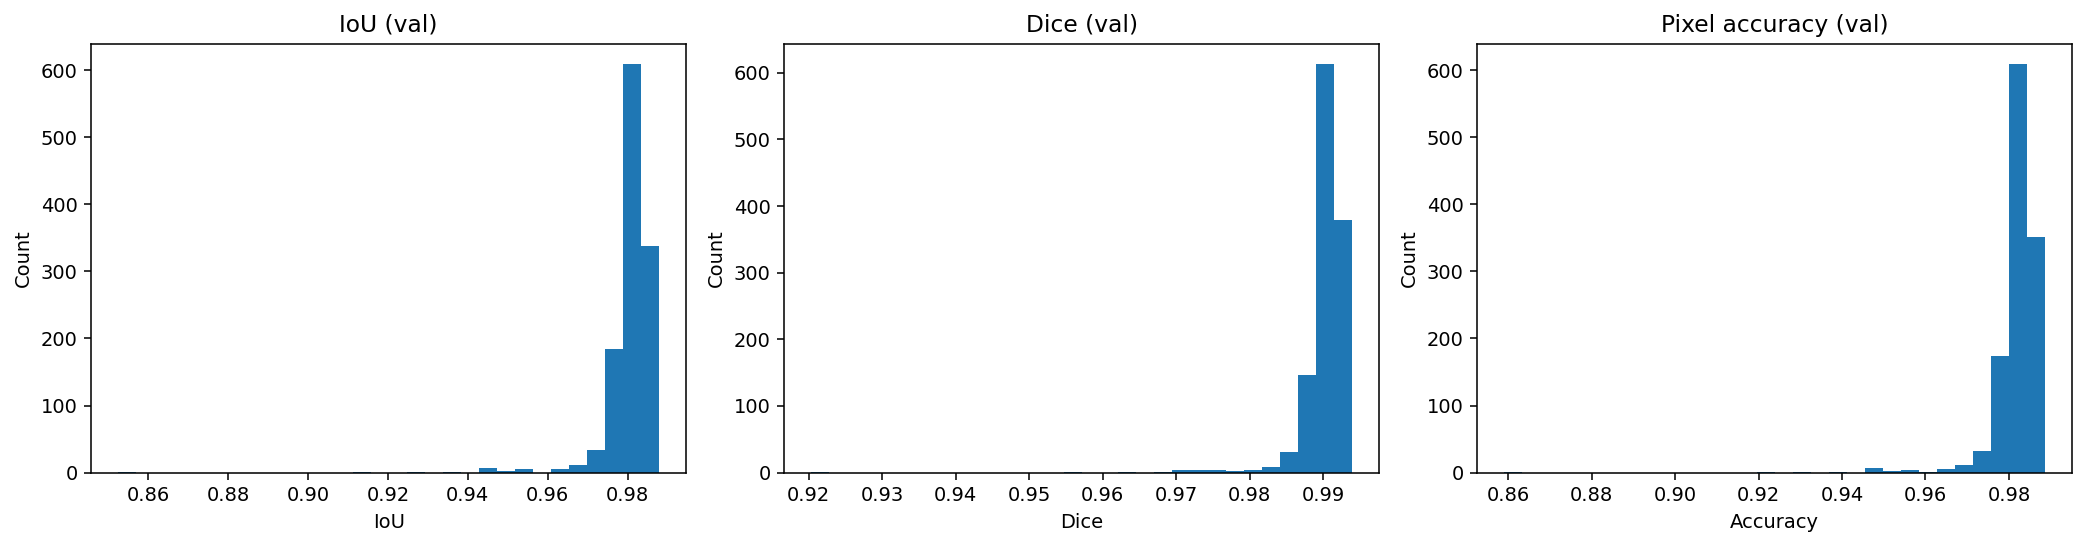

Saved histogram: ./latent_dim_sweep_20260303_110401/recon_metrics_hist_D32.png


In [ ]:
# =========================
# Reconstruction quality on the validation set:
# IoU, Dice, and pixel accuracy
# Also plots histograms and saves the figure
# =========================

# ----------------------------
# 1) Select the model for the chosen latent dimension
# ----------------------------
model_eval = None

# First preference:
# use an explicitly stored chosen model if available
if "model_chosen" in globals():
    model_eval = model_chosen

# Second preference:
# use a model saved in a dictionary during the latent-dimension sweep
elif "trained_models" in globals() and "chosen" in globals() and chosen in trained_models:
    model_eval = trained_models[chosen]

# Third preference:
# use the last trained model if it matches the chosen latent dimension
elif "model_D" in globals() and "chosen" in globals() and getattr(model_D, "latent_dim", None) == chosen:
    model_eval = model_D

# If no suitable model is found in memory, retrain the chosen latent dimension
# using the existing training/validation loaders and settings
if model_eval is None:
    assert "chosen" in globals(), "chosen not found. Run the sweep cell first."
    print(f"No in-memory model found for D={chosen}. Retraining D={chosen} for evaluation...")
    model_eval, _, _ = train_vae_one_quiet(
        latent_dim=chosen,
        train_loader=train_loader,
        val_loader=val_loader,
        image_size=image_size,
        lr=learning_rate,
        beta_kl=beta_kl,
        epochs=epochs,
        patience=patience,
        min_delta=min_delta,
        device=device,
        print_every=50  # print only occasionally
    )

# Move the selected model to the target device and switch to evaluation mode
model_eval = model_eval.to(device)
model_eval.eval()

# ----------------------------
# 2) Define reconstruction metric function
# ----------------------------
@torch.no_grad()
def recon_metrics_on_loader(model, loader, device, thr=0.5, eps=1e-8):
    """
    Compute reconstruction metrics over a DataLoader.

    Metrics:
    - IoU (intersection over union)
    - Dice coefficient
    - Pixel accuracy

    Parameters
    ----------
    model : torch.nn.Module
        Trained reconstruction model.
    loader : DataLoader
        DataLoader containing validation samples.
    device : torch.device
        Device on which evaluation is performed.
    thr : float
        Threshold used to binarize reconstructed outputs.
    eps : float
        Small constant for numerical stability.

    Returns
    -------
    ious : np.ndarray
        Per-sample IoU values.
    dices : np.ndarray
        Per-sample Dice values.
    accs : np.ndarray
        Per-sample pixel accuracies.
    """
    ious, dices, accs = [], [], []

    for x in loader:
        # Ground-truth binary masks, expected shape [B,1,H,W]
        x = x.to(device)

        # Reconstructed masks from the model, values in [0,1]
        recon, _, _ = model(x)

        # Binarize predictions and targets
        pred = (recon > thr).float()
        targ = (x > 0.5).float()

        # Compute intersection and union for IoU
        inter = (pred * targ).sum(dim=(1, 2, 3))
        union = (pred + targ - pred * targ).sum(dim=(1, 2, 3))
        iou = (inter + eps) / (union + eps)

        # Compute Dice coefficient
        pred_sum = pred.sum(dim=(1, 2, 3))
        targ_sum = targ.sum(dim=(1, 2, 3))
        dice = (2 * inter + eps) / (pred_sum + targ_sum + eps)

        # Compute pixel-wise accuracy
        acc = (pred == targ).float().mean(dim=(1, 2, 3))

        # Store batch results
        ious.append(iou.detach().cpu().numpy())
        dices.append(dice.detach().cpu().numpy())
        accs.append(acc.detach().cpu().numpy())

    # Concatenate results from all batches into full arrays
    ious = np.concatenate(ious)
    dices = np.concatenate(dices)
    accs = np.concatenate(accs)

    return ious, dices, accs

# Evaluate reconstruction metrics on the validation set
ious, dices, accs = recon_metrics_on_loader(model_eval, val_loader, device=device, thr=0.5)

# Print summary statistics
print(f"Recon metrics on VAL (D={getattr(model_eval, 'latent_dim', 'unknown')}):")
print(f"  IoU:  mean={ious.mean():.4f},  std={ious.std(ddof=1):.4f}")
print(f"  Dice: mean={dices.mean():.4f}, std={dices.std(ddof=1):.4f}")
print(f"  Acc:  mean={accs.mean():.4f},  std={accs.std(ddof=1):.4f}")

# ----------------------------
# 3) Plot histograms of reconstruction metrics and save
# ----------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of IoU values
axs[0].hist(ious, bins=30)
axs[0].set_title("IoU (val)")
axs[0].set_xlabel("IoU")
axs[0].set_ylabel("Count")

# Histogram of Dice values
axs[1].hist(dices, bins=30)
axs[1].set_title("Dice (val)")
axs[1].set_xlabel("Dice")
axs[1].set_ylabel("Count")

# Histogram of pixel accuracies
axs[2].hist(accs, bins=30)
axs[2].set_title("Pixel accuracy (val)")
axs[2].set_xlabel("Accuracy")
axs[2].set_ylabel("Count")

# Adjust layout
plt.tight_layout()

# Save the histogram figure
out_dir = save_dir if "save_dir" in globals() else "."
out_path = os.path.join(out_dir, f"recon_metrics_hist_D{getattr(model_eval, 'latent_dim', 'X')}.png")
plt.savefig(out_path)

# Show the figure
plt.show()

# Print save location
print("Saved histogram:", out_path)

**Outcome.** Reconstruction overlap metrics are consistently high on the validation set, indicating that the selected VAE retains the morphological information required for downstream analysis.

### Step 8 & 9 — Latent usage and orientation stability checks (KL-per-dimension + D4 invariance)

Before using the latent space for distribution-level comparisons (e.g., MMD and Wasserstein distances), we perform two simple sanity checks to verify that the embedding is (i) *used* by the model and (ii) *stable* to arbitrary image orientation.

**i) Latent usage via per-dimension KL contributions.**  
For each latent coordinate $z_j$, we compute its average KL divergence contribution on the validation set. This provides an “activity” measure for each dimension: if many dimensions have near-zero KL, the VAE is effectively collapsing to a smaller latent space. A smoothly decaying, non-zero KL profile across dimensions indicates that the model is using the latent capacity and distributing morphology information across multiple coordinates.

**ii) D4 invariance / stability of the embedding.**  
Microring images have no preferred orientation, so the embedding should not change strongly under rotations or flips. We therefore encode the **same** ring under D4 transforms (rotations by $0^\circ/90^\circ/180^\circ/270^\circ$ and flips) and compute **within-ring** latent distances, i.e., how far the latent mean $\mu$ moves when only the orientation changes. We compare this to **between-ring** distances computed from randomly chosen pairs of different rings. If the within-ring distances are systematically smaller than between-ring distances, it indicates that the latent representation is largely insensitive to rotations/flips and that latent distances primarily reflect genuine morphology differences rather than orientation.

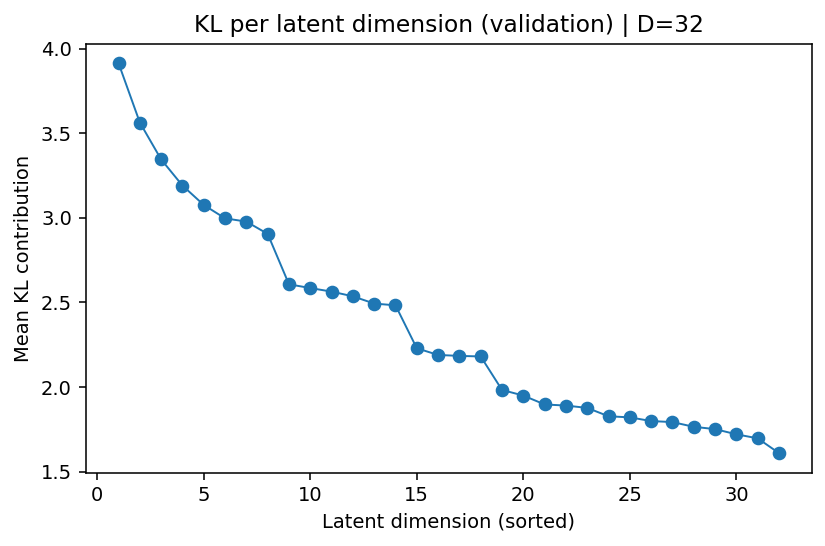

Saved: ./latent_dim_sweep_20260303_110401/kl_per_dim_D32.png


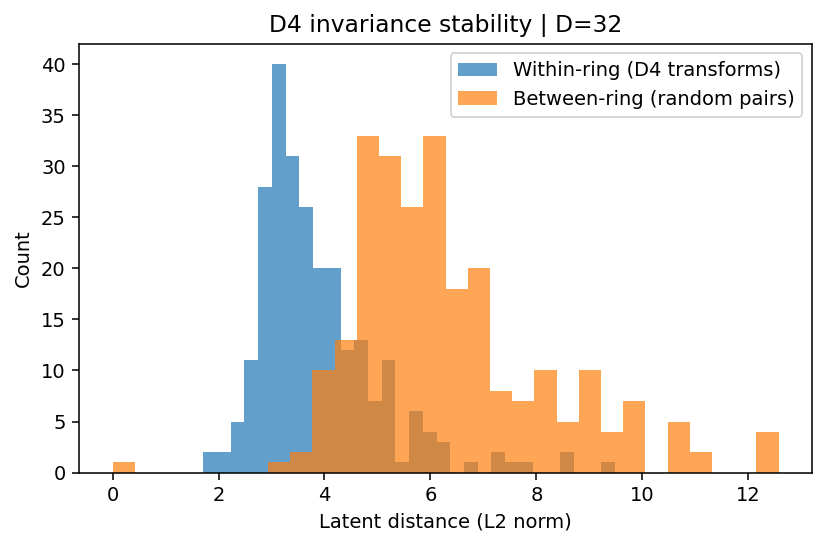

Saved: ./latent_dim_sweep_20260303_110401/d4_invariance_D32.png
Median within: 3.583407402038574 | Median between: 6.0073323249816895


In [ ]:
# =========================
# 1. Mean KL contribution per latent dimension
# 2. D4 invariance stability in latent space
# =========================

# Use the previously selected latent dimension
D = chosen

# Make sure the evaluation model is in inference mode
model_eval.eval()

# ----------------------------
# (1) KL contribution per latent dimension on the validation set
# ----------------------------
@torch.no_grad()
def kl_per_dim(model, loader, device):
    """
    Compute the mean KL contribution of each latent dimension
    across all samples in a DataLoader.

    Parameters
    ----------
    model : VAE
        Trained VAE model.
    loader : DataLoader
        DataLoader containing the evaluation samples.
    device : torch.device
        Device on which computation is performed.

    Returns
    -------
    np.ndarray
        Mean KL contribution for each latent dimension.
    """
    model.eval()

    # Number of latent dimensions
    D = model.latent_dim

    # Accumulate KL contribution per dimension
    kl_sum = torch.zeros(D, device=device)

    # Count total number of samples processed
    n = 0

    for x in loader:
        x = x.to(device)

        # Encode input into latent distribution parameters
        mu, logvar = model.encode(x)

        # Per-sample, per-dimension KL term
        # Shape: [batch_size, D]
        kl = 0.5 * (mu.pow(2) + logvar.exp() - 1.0 - logvar)

        # Sum over the batch and accumulate
        kl_sum += kl.sum(dim=0)
        n += x.size(0)

    # Average KL contribution per dimension across all samples
    kl_mean = (kl_sum / max(n, 1)).detach().cpu().numpy()

    return kl_mean

# Compute mean KL per latent dimension
kl_mean = kl_per_dim(model_eval, val_loader, device=device)

# Sort KL values in descending order for easier visualization
kl_sorted = np.sort(kl_mean)[::-1]

# Plot sorted KL contributions
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(kl_sorted) + 1), kl_sorted, marker="o", linewidth=1)
plt.xlabel("Latent dimension (sorted)")
plt.ylabel("Mean KL contribution")
plt.title(f"KL per latent dimension (validation) | D={D}")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"kl_per_dim_D{D}.png"))
plt.show()

print("Saved:", os.path.join(save_dir, f"kl_per_dim_D{D}.png"))

# ----------------------------
# (2) D4 invariance stability in latent space
# ----------------------------
@torch.no_grad()
def encode_mu_single(model, mask_np, device):
    """
    Encode a single mask and return its latent mean vector.

    Parameters
    ----------
    model : VAE
        Trained VAE model.
    mask_np : np.ndarray
        One mask with shape (H, W).
    device : torch.device
        Device on which encoding is performed.

    Returns
    -------
    np.ndarray
        Latent mean vector for the input mask.
    """
    x = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float().to(device)
    mu, _ = model.encode(x)
    return mu.squeeze(0).cpu().numpy()

@torch.no_grad()
def d4_mus(model, mask_np, device):
    """
    Encode one mask under multiple D4-style transformations:
    4 rotations, and for each rotation:
    - the rotated image
    - left-right flipped version
    - up-down flipped version

    Total variants = 12

    Parameters
    ----------
    model : VAE
        Trained VAE model.
    mask_np : np.ndarray
        One mask with shape (H, W).
    device : torch.device
        Device on which encoding is performed.

    Returns
    -------
    np.ndarray
        Array of latent mean vectors with shape [12, D].
    """
    x = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float().to(device)
    mus = []

    for k in range(4):
        # Rotate by k * 90 degrees
        rot = torch.rot90(x, k, dims=(2, 3))

        # Encode rotated mask
        mu, _ = model.encode(rot)
        mus.append(mu.squeeze(0).cpu().numpy())

        # Encode left-right flipped rotated mask
        mu, _ = model.encode(torch.fliplr(rot))
        mus.append(mu.squeeze(0).cpu().numpy())

        # Encode up-down flipped rotated mask
        mu, _ = model.encode(torch.flipud(rot))
        mus.append(mu.squeeze(0).cpu().numpy())

    return np.vstack(mus)  # shape [12, D]

def invariance_diagnostic(model, masks_np, n=200, seed=0):
    """
    Compare:
    - within-ring latent variation under D4 transforms
    - between-ring latent variation for random ring pairs

    Parameters
    ----------
    model : VAE
        Trained VAE model.
    masks_np : array-like
        Collection of processed masks.
    n : int
        Number of masks to sample for the diagnostic.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    within : np.ndarray
        Mean within-ring latent distances under D4 transforms.
    between : np.ndarray
        Latent distances between random pairs of different sampled rings.
    """
    rng = np.random.default_rng(seed)

    # Randomly sample mask indices
    idx = rng.choice(len(masks_np), size=min(n, len(masks_np)), replace=False)

    # -------------------------
    # Within-ring distances:
    # for each ring, compare latent vectors across D4 transforms
    # -------------------------
    within = []
    for i in idx:
        # Latent means for 12 transformed versions of one ring
        M = d4_mus(model, masks_np[i], device=device)  # [12, D]

        # Mean latent vector across transforms
        mu0 = M.mean(axis=0, keepdims=True)

        # Average L2 distance of each transformed version from the mean
        within.append(np.mean(np.linalg.norm(M - mu0, axis=1)))

    within = np.array(within)

    # -------------------------
    # Between-ring distances:
    # compare latent vectors of random pairs of different sampled rings
    # -------------------------
    mus_single = np.vstack([
        encode_mu_single(model, masks_np[i], device=device) for i in idx
    ])

    # Random index pairs
    pairs = rng.integers(0, len(idx), size=(len(idx), 2))

    # L2 distance between randomly paired rings
    between = np.linalg.norm(
        mus_single[pairs[:, 0]] - mus_single[pairs[:, 1]],
        axis=1
    )

    return within, between

# Get processed masks from the dataframe
masks_np = df["binary_proc"].values

# Run invariance diagnostic
within, between = invariance_diagnostic(model_eval, masks_np, n=250, seed=SEED)

# Plot histogram comparing within-ring and between-ring latent distances
plt.figure(figsize=(6, 4))
plt.hist(within, bins=30, alpha=0.7, label="Within-ring (D4 transforms)")
plt.hist(between, bins=30, alpha=0.7, label="Between-ring (random pairs)")
plt.xlabel("Latent distance (L2 norm)")
plt.ylabel("Count")
plt.title(f"D4 invariance stability | D={D}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"d4_invariance_D{D}.png"))
plt.show()

print("Saved:", os.path.join(save_dir, f"d4_invariance_D{D}.png"))
print("Median within:", float(np.median(within)), "| Median between:", float(np.median(between)))

**Outcome.**
- KL contributions are non-trivial across all latent dimensions, suggesting the model uses the full latent space and distributes morphology information across multiple coordinates.
- Within-ring D4 distances are systematically smaller than between-ring distances for random ring pairs, indicating that the embedding is largely insensitive to rotations/flips and primarily reflects morphology differences.

### Summary: selected latent dimensionality

Across all diagnostics, $d_z=32$ provides a strong balance between predictive utility and compactness:
- Near-optimal downstream gain in corrected threshold prediction ($\Delta R^2$) with a conservative 1-SE selection rule;
- Faithful reconstructions (qualitative and IoU/Dice overlap);
- Stable embeddings under D4 transforms;
- Non-collapsed latent usage (per-dimension KL).

We therefore use $d_z=32$ for all subsequent latent-space distribution analyses (e.g., MMD and Wasserstein distance comparisons between fields).